Namw:Ujjawal chauhan
CU24250259 roll no:62
 labsheet -03


In [64]:
import pandas as pd

df = pd.read_csv("/workspaces/Mastery_in_DataAnalytics_and_Visualizations_and_Career_Advancemen/WA_Fn-UseC_-HR-Employee-Attrition-selected-columns.csv")

print(df.head())
print(df.shape)
print(df.columns.tolist())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  
0                 1          2  Life Sciences              1               1  
1                 8          1  Life Sciences              1               2  
2                 2          2          Other              1               4  
3                 3          4  Life Sciences              1               5  
4                 2          1        Medical              1               7  
(1470, 10)
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'Dis

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

In [66]:
print("Mean:")
print(df[["Age", "DailyRate", "DistanceFromHome"]].mean())

print("\nMedian:")
print(df[["Age", "DailyRate", "DistanceFromHome"]].median())

print("\nMode:")
print(df[["Age", "DailyRate", "DistanceFromHome"]].mode().iloc[0])

print("\nVariance:")
print(df[["Age", "DailyRate", "DistanceFromHome"]].var())

print("\nStandard Deviation:")
print(df[["Age", "DailyRate", "DistanceFromHome"]].std())

Mean:
Age                  36.923810
DailyRate           802.485714
DistanceFromHome      9.192517
dtype: float64

Median:
Age                  36.0
DailyRate           802.0
DistanceFromHome      7.0
dtype: float64

Mode:
Age                  35
DailyRate           691
DistanceFromHome      2
Name: 0, dtype: int64

Variance:
Age                     83.455049
DailyRate           162819.593737
DistanceFromHome        65.721251
dtype: float64

Standard Deviation:
Age                   9.135373
DailyRate           403.509100
DistanceFromHome      8.106864
dtype: float64


In [67]:
print(df[["Age", "DailyRate", "DistanceFromHome"]].describe())

               Age    DailyRate  DistanceFromHome
count  1470.000000  1470.000000       1470.000000
mean     36.923810   802.485714          9.192517
std       9.135373   403.509100          8.106864
min      18.000000   102.000000          1.000000
25%      30.000000   465.000000          2.000000
50%      36.000000   802.000000          7.000000
75%      43.000000  1157.000000         14.000000
max      60.000000  1499.000000         29.000000


In [68]:
numeric_df = df[["Age", "DailyRate", "DistanceFromHome"]]

correlation = numeric_df.corr()

print(correlation)

                       Age  DailyRate  DistanceFromHome
Age               1.000000   0.010661         -0.001686
DailyRate         0.010661   1.000000         -0.004985
DistanceFromHome -0.001686  -0.004985          1.000000


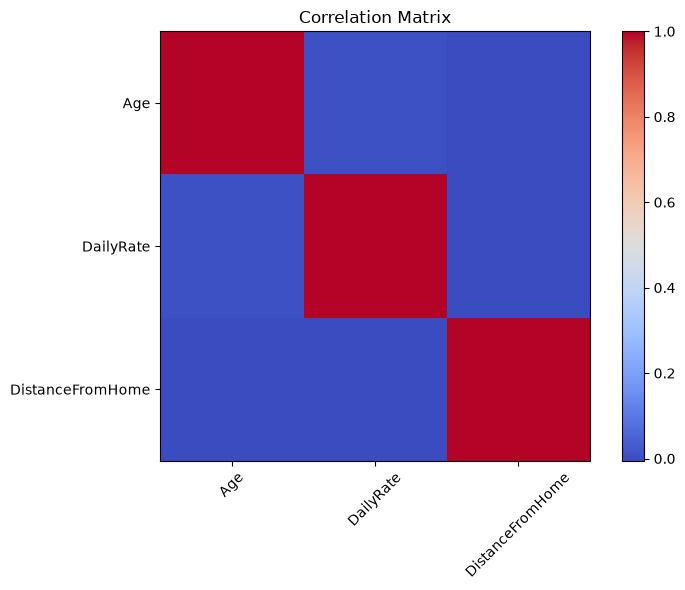

In [69]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation, cmap="coolwarm")
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [70]:
r, p = stats.pearsonr(df["Age"], df["DailyRate"])

print("Pearson Correlation:", r)
print("P-value:", p)

Pearson Correlation: 0.01066094264553816
P-value: 0.6829722453880914


In [71]:
left = df[df["Attrition"] == "Yes"]["Age"]

stayed = df[df["Attrition"] == "No"]["Age"]

print("Employees who left:", len(left))
print("Employees who stayed:", len(stayed))

Employees who left: 237
Employees who stayed: 1233


In [72]:
t_stat, p_value = stats.ttest_ind(
    left,
    stayed,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -5.82801185398895
P-value: 1.3797600649439802e-08


In [73]:
if p_value < 0.05:
    print("Reject H0")
    print("There is a significant difference in Age between employees who left and stayed.")
else:
    print("Fail to reject H0")
    print("There is no significant difference in Age between employees who left and stayed.")

Reject H0
There is a significant difference in Age between employees who left and stayed.


In [74]:
print(df["Department"].unique())

<StringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str


In [75]:
groups = []

for department in df["Department"].unique():
    groups.append(
        df[df["Department"] == department]["Age"]
    )

In [76]:
f_stat, p_value_anova = stats.f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value_anova)

F-statistic: 0.7655031924976907
P-value: 0.4652855299935297


In [77]:
if p_value_anova < 0.05:
    print("Reject H0")
    print("There is a significant difference in Age among Departments.")
else:
    print("Fail to reject H0")
    print("There is no significant difference in Age among Departments.")

Fail to reject H0
There is no significant difference in Age among Departments.


In [78]:
X = df["Age"]
y = df["DailyRate"]

In [79]:
X = sm.add_constant(X)

In [80]:
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              DailyRate   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.1669
Date:                Mon, 31 Aug 2026   Prob (F-statistic):              0.683
Time:                        08:31:36   Log-Likelihood:                -10906.
No. Observations:                1470   AIC:                         2.182e+04
Df Residuals:                    1468   BIC:                         2.183e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        785.0985     43.847     17.905      0.0

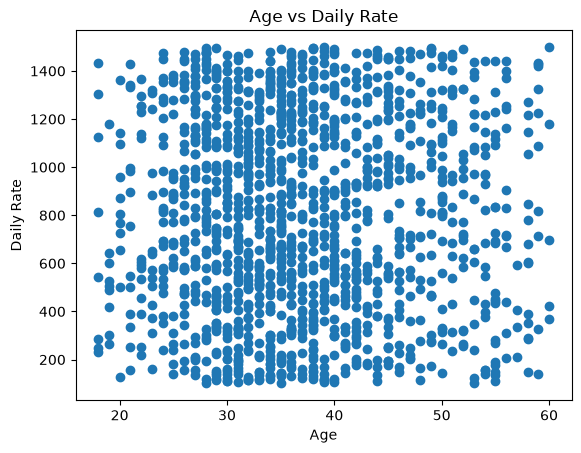

In [81]:
plt.scatter(df["Age"], df["DailyRate"])

plt.xlabel("Age")
plt.ylabel("Daily Rate")
plt.title("Age vs Daily Rate")

plt.show()

In [82]:
print("R-squared:", model.rsquared)

R-squared: 0.00011365569809163034


In [83]:
print("Regression Coefficients:")
print(model.params)

Regression Coefficients:
const    785.098535
Age        0.470893
dtype: float64


In [84]:
print("P-values:")
print(model.pvalues)

P-values:
const    5.267571e-65
Age      6.829722e-01
dtype: float64


In [85]:
print("Confidence Intervals:")
print(model.conf_int())

Confidence Intervals:
                0           1
const  699.089362  871.107708
Age     -1.790341    2.732128


In [86]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              DailyRate   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.1669
Date:                Mon, 31 Aug 2026   Prob (F-statistic):              0.683
Time:                        08:31:37   Log-Likelihood:                -10906.
No. Observations:                1470   AIC:                         2.182e+04
Df Residuals:                    1468   BIC:                         2.183e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        785.0985     43.847     17.905      0.0

In [87]:
print("STATISTICAL ANALYSIS SUMMARY")
print("=" * 40)

print("\n1. T-TEST")
print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Significant difference in Age.")
else:
    print("Result: No significant difference in Age.")

print("\n2. ANOVA")
print("F-statistic:", f_stat)
print("P-value:", p_value_anova)

if p_value_anova < 0.05:
    print("Result: Significant difference among Departments.")
else:
    print("Result: No significant difference among Departments.")

print("\n3. LINEAR REGRESSION")
print("R-squared:", model.rsquared)
print("Age coefficient:", model.params["Age"])
print("Age p-value:", model.pvalues["Age"])

STATISTICAL ANALYSIS SUMMARY

1. T-TEST
T-statistic: -5.82801185398895
P-value: 1.3797600649439802e-08
Result: Significant difference in Age.

2. ANOVA
F-statistic: 0.7655031924976907
P-value: 0.4652855299935297
Result: No significant difference among Departments.

3. LINEAR REGRESSION
R-squared: 0.00011365569809163034
Age coefficient: 0.47089343162226616
Age p-value: 0.6829722453880929
